## Explore Coarse-graining

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

import copy
import matplotlib.patches as patches
from collections import Counter, defaultdict
import matplotlib.cm as cm
import json
import pandas as pd

import sys
sys.path.insert(1, 'analysis')
from hex_helpers import * # functions written in scripts/hex_helpers.py for working with hexagons

## load data

In [2]:
trajectories = pickle.load( open( "analysis/data/full_days.p", "rb" ) )
event_radii = pickle.load( open( "analysis/data/final_event_radii.p", "rb" ) )
origins = pickle.load(open( "analysis/data/select_origins.p", "rb" ) )

box_breaks = json.load(open('analysis/data/centroid_outside_box.json','r'))

baboon_info = pd.read_csv('analysis/data/baboon_info.csv',index_col=0)
baboon_info['ID'] = baboon_info.index

In [3]:
r_days =  [1,2,4,7,9,] # 15,17,18,20
l_days =  [3,5,6,8,10,11,12,13,14] 
# n_days = [21,26,29,33]

In [4]:
baboons = [b for b in list(trajectories[1].keys()) if b not in ['centroid','active']]
days = list(trajectories.keys())
decision_days = r_days+l_days

## reproduce coarse-graining

In [5]:
hex_size = 4
event_radius = hex_size*event_radii[hex_size]
origin_id = 0
shift = hex_size * origins[origin_id]

In [6]:
event_times = pickle.load( open( "analysis/data/coarse_grainings/%.3f/%d.p"%(hex_size,origin_id), "rb" ) )

In [7]:
coarse_graining = {day:{} for day in days}
hex_counts = defaultdict(int)
day_counts = defaultdict(int)
baboon_counts = defaultdict(int)
left_right_counts = defaultdict(list)
total_counts = 0

In [8]:
for day in decision_days: # box_breaks.keys(): # days:
    day = int(day)
    day_hexes = []
    for baboon in baboons:
        splits = copy.deepcopy(event_times[day][baboon])
        splits = splits[splits < box_breaks[str(day)]]
        baboon_hexes = []
        if not np.all(np.isnan(splits)):
            xy_traj = trajectories[day][baboon] - shift 
            hex_traj = xy_traj_to_qr_traj(xy_traj,hex_size)#.astype(int)
            
            coarse_hexes = []
            for start,end in np.vstack((splits,np.r_[splits[1:],xy_traj.shape[0]])).T:
                coarse_hexes.append(np.tile(hex_traj[start], (end - start,1)))
                if np.sum(np.isnan(hex_traj[start]))  == 0:
                    hex_key = tuple(hex_traj[start].astype(int))
                    hex_counts[hex_key] += 1#(end - start)
                    
                    if hex_key not in day_hexes:
                        day_counts[hex_key] += 1
                        day_hexes.append(hex_key)
                    if hex_key not in baboon_hexes:
                        left_right_counts[hex_key].append(day)
                        baboon_counts[hex_key] += 1
                        baboon_hexes.append(hex_key)
                        
                    
                    
                    total_counts += 1 # (end-start)

            
            change_points = np.zeros(xy_traj.shape[0])
            change_points[splits] += 1
            
            coarse_graining[day][baboon] = np.hstack((change_points.reshape(-1,1),
                                                      np.vstack(coarse_hexes),
                                                      xy_traj))

In [9]:
unique_hex = np.array(list(hex_counts.keys()))

# Build Left Right Probability Map 

In [10]:
hex_colors = plt.colormaps['viridis']

def visualize_hex_map_simple_counts(counts):
    max_counts = max(counts.values())
    fig, axes = plt.subplots(1,1,figsize=(8,6))

    all_centers = []
    for q,r in unique_hex:
        xy = qr_to_xy(q,r,hex_size)
        all_centers.append((xy[0],xy[1]))

        if (q,r) in counts.keys():
            poly = patches.RegularPolygon(xy,numVertices=6,orientation=0,
                                              radius=hex_size,
                                              alpha=0.4, ec='k',fill=True,
                                              fc=hex_colors(counts[(q,r)]/max_counts))
        else:
            poly = patches.RegularPolygon(xy,numVertices=6,orientation=0,
                                              radius=hex_size,
                                              alpha=0.4, ec='k',fill=False)
        axes.add_patch(poly)

    min_max = np.array([np.min(np.array(all_centers).T,axis=1),np.max(np.array(all_centers).T,axis=1)])
    plt.xlim(min_max[0,0]-10,min_max[1,0]+10)
    plt.ylim(min_max[0,1]-10,min_max[1,1]+10)

    plt.show()
    
def visualize_hex_map_beta_counts(counts):
    fig, axes = plt.subplots(1,1,figsize=(16,12))
    max_counts = max([sum(v) for v in counts.values()])
    all_centers = []
    for q,r in unique_hex:
        xy = qr_to_xy(q,r,hex_size)
        all_centers.append((xy[0],xy[1]))
        sum_counts = (counts[(q,r)][0]+counts[(q,r)][1])
        prob = counts[(q,r)][1]/sum_counts
        poly = patches.RegularPolygon(xy,numVertices=6,orientation=0,
                                          radius=hex_size,
                                          #alpha=np.clip(sum_counts/max_counts,.08,1),
                                          alpha=.4,
                                          ec='k',fill=True,
                                          fc=hex_colors(prob))
        axes.add_patch(poly)

    min_max = np.array([np.min(np.array(all_centers).T,axis=1),np.max(np.array(all_centers).T,axis=1)])
    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)
    plt.xlim(min_max[0,0]-10,min_max[1,0]+10)
    plt.ylim(min_max[0,1]-10,min_max[1,1]+10)
    plt.savefig('figures/lrprob.png',facecolor='white',bbox_inches='tight',dpi=150)
    plt.show()

In [11]:
target_day = 1
hex_beginnings = defaultdict(int)
hex_l_endings = defaultdict(int)
hex_r_endings = defaultdict(int)

In [12]:
for day in decision_days:
    if day != target_day:
        for baboon in coarse_graining[int(day)].keys():
            cg = coarse_graining[int(day)][baboon]
            # timestep, baboon, split, hex, hex, x, y
            rich_cg = np.vstack((np.arange(cg.shape[0]),
                       np.tile(baboon,cg.shape[0]),
                       cg.T)).T

            split_cg = rich_cg[cg.T[0] == 1][np.isnan(rich_cg[cg.T[0] == 1]).sum(axis=1) == 0]
            
            if split_cg[0,0] < 60:
                hex_beginnings[tuple(split_cg[0,3:5].astype(int))] += 1
            
            if rich_cg[np.isnan(rich_cg).sum(axis=1) == 0][-1,0] > box_breaks[str(day)]:
                if int(day) in r_days:
                    hex_r_endings[tuple(split_cg[-1,3:5].astype(int))] += 1
                else:
                    hex_l_endings[tuple(split_cg[-1,3:5].astype(int))] += 1


In [13]:
def hex_dist_hex(q,r,a,b):
    return np.abs(np.array(axial_to_cube(q,r)) -
                  np.array(axial_to_cube(a,b))).sum()/2

In [14]:
hex_priors = {(q,r):np.array((0.,0.)) for q,r in unique_hex}

hex_prior_extras = {}
for (q,r),prior in hex_priors.items():
    extra = np.zeros(2)
    
    for (a,b),v in hex_beginnings.items():
        extra += .5*v/(1+hex_dist_hex(q,r,a,b)**2)
        
    for (a,b),v in hex_l_endings.items():
        extra[0] += v/(1+hex_dist_hex(q,r,a,b)**2)
        
    for (a,b),v in hex_r_endings.items():
        extra[1] += v/(1+hex_dist_hex(q,r,a,b)**2)
        
    extra = 2 * (extra / sum(extra))
    hex_prior_extras[(q,r)] = prior + extra

In [15]:
for k in left_right_counts.keys():
    if len(np.unique(left_right_counts[k])) == 1:
        adjustment = 1.
    else:
        adjustment = 1.
    for d in left_right_counts[k]:
        if d == target_day:
            continue
        elif d in r_days:
            hex_prior_extras[k][1] += adjustment*1
        elif d in l_days:
            hex_prior_extras[k][0] += adjustment*1
        else:
            continue

In [16]:
def get_hex_neighbors(q,r):
    return([(q-1,r),(q+1,r),
            (q,r-1),(q,r+1),
            (q-1,r+1),(q+1,r-1)])

In [17]:
hex_smoothed = {}
for (q,r),extra in hex_prior_extras.items():
    smoothing = np.zeros(2)
    for (a,b) in get_hex_neighbors(q,r):
        if (a,b) in hex_prior_extras.keys():
            smoothing += hex_prior_extras[(a,b)]
    hex_smoothed[(q,r)] = extra + smoothing/6.

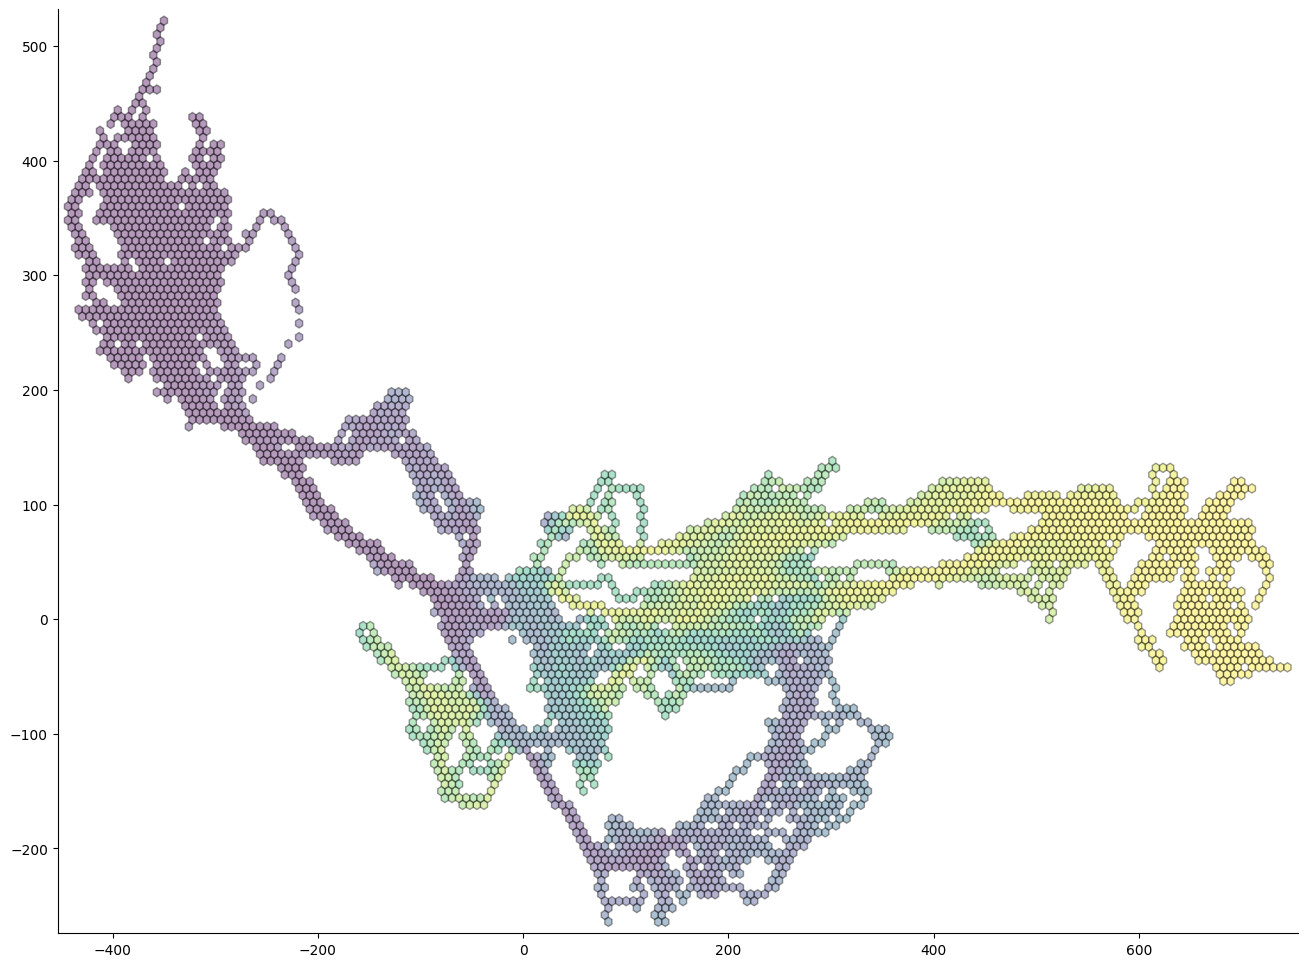

In [18]:
visualize_hex_map_beta_counts(hex_smoothed)